In [50]:
import cv2
import matplotlib.pyplot as plt
import time
import numpy as np

cv2.namedWindow("color_mask")

cv2.createTrackbar("b_low", "color_mask", 67, 255, lambda i : i)
cv2.createTrackbar("g_low", "color_mask", 55, 255, lambda i : i)
cv2.createTrackbar("r_low", "color_mask", 224, 255, lambda i : i)
cv2.createTrackbar("b_high", "color_mask", 189, 255, lambda i : i)
cv2.createTrackbar("g_high", "color_mask", 139, 255, lambda i : i)
cv2.createTrackbar("r_high", "color_mask", 255, 255, lambda i : i)

# def print_val(i):
#     print(i)

# cv2.createTrackbar("b_low", "color_mask", 0, 255, print_val)

cam = cv2.VideoCapture(0)

while(True):
    ret, frame_ = cam.read()
    
    sh = frame_.shape
    
    frame = cv2.resize(frame_, (sh[1] // 2, sh[0] // 2))
    
    b_low = cv2.getTrackbarPos("b_low", "color_mask")
    g_low = cv2.getTrackbarPos("g_low", "color_mask")
    r_low = cv2.getTrackbarPos("r_low", "color_mask")
    b_high = cv2.getTrackbarPos("b_high", "color_mask")
    g_high = cv2.getTrackbarPos("g_high", "color_mask")
    r_high = cv2.getTrackbarPos("r_high", "color_mask")
    
    mask = cv2.inRange(frame, (b_low, g_low, r_low), (b_high, g_high, r_high))
    
    output = cv2.connectedComponentsWithStats(mask)
    
    num_components = output[0]
    #labels = output[1]
    stats = output[2]
    
    for i in range(num_components):
        top    = stats[i, cv2.CC_STAT_TOP]
        left   = stats[i, cv2.CC_STAT_LEFT]
        width  = stats[i, cv2.CC_STAT_WIDTH]
        height = stats[i, cv2.CC_STAT_HEIGHT]
        area   = stats[i, cv2.CC_STAT_AREA]
        
        cv2.rectangle(frame, (left, top), (left + width, top + height), (123, 234, 234), 2)

    cv2.imshow("frame", frame)
    cv2.imshow("color_mask", mask)

    key = cv2.waitKey(30) & 0xFF

    if (key == ord('q')):
        break

cam.release()
cv2.destroyAllWindows()
cv2.waitKey(30)

-1

[[1 1 1]
 [1 1 1]
 [1 1 1]]


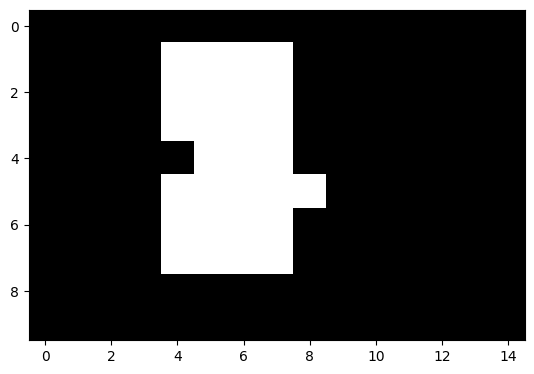

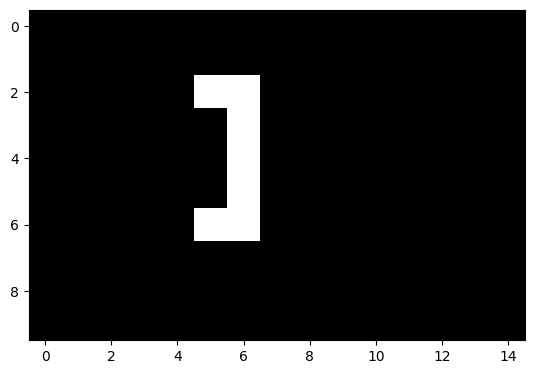

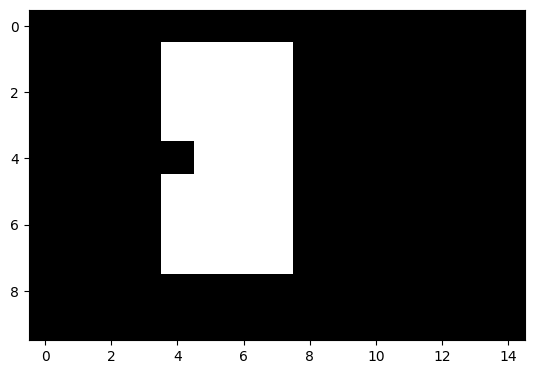

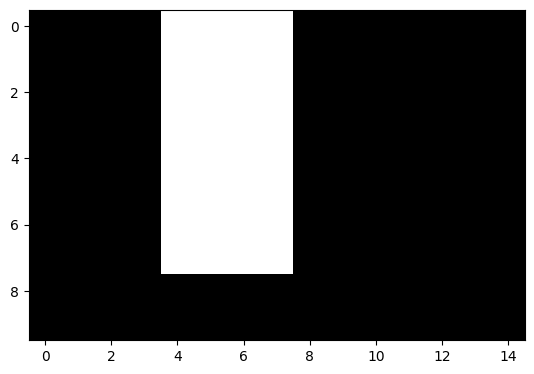

In [42]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

mask = np.zeros((10, 15), np.uint8)

mask[1:8, 4:8] = 255
mask[5:6, 7:9] = 255
mask[4:5, 4:5] = 0

#print(mask)

kernel = np.ones((3, 3), np.uint8)

print(kernel)

eroded  = cv2.erode(mask, kernel)
dilated = cv2.dilate(eroded, kernel)

closed = cv2.morphologyEx(dilated, cv2.MORPH_CLOSE, kernel)

plt.imshow(mask, cmap="gray")
plt.show()
plt.imshow(eroded, cmap="gray")
plt.show()
plt.imshow(dilated, cmap="gray")
plt.show()
plt.imshow(closed, cmap="gray")
plt.show()

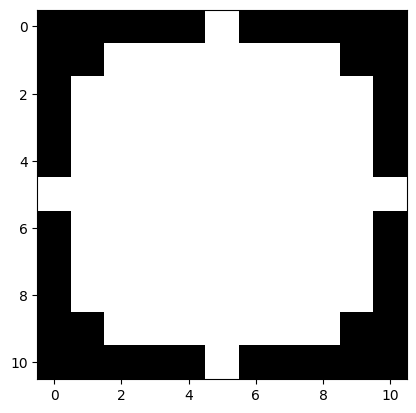

In [48]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

mask = np.zeros((11, 11), np.uint8)

cv2.circle(mask, (5, 5), 5, 255, -1)

plt.imshow(mask, cmap="gray")
plt.show()

In [ ]:
import cv2
import matplotlib.pyplot as plt
import time
import numpy as np

cam = cv2.VideoCapture(0)

while(True):
    ret, frame_ = cam.read()
    
    sh = frame_.shape
    
    frame = cv2.resize(frame_, (sh[1] // 2, sh[0] // 2))
    
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    
    cv2.imshow("frame", frame)
    #cv2.imshow("frame0", frame[:, :, 0])
    #cv2.imshow("frame1", frame[:, :, 1])
    #cv2.imshow("frame2", frame[:, :, 2])

    cv2.imshow("hsv", hsv)
    cv2.imshow("h", hsv[:, :, 0])
    cv2.imshow("s", hsv[:, :, 1])
    cv2.imshow("v", hsv[:, :, 2])
    
    key = cv2.waitKey(30) & 0xFF

    if (key == ord('q')):
        break

cam.release()
cv2.destroyAllWindows()
cv2.waitKey(30)

-1

: 